# Visual Product Recommendation System

**Goal:** given a fashion product image, find visually similar products in a catalog — no text search involved.

This notebook builds the system in three increasingly better stages, exactly as described in the project brief:

1. **Baseline** — embeddings from an off-the-shelf CNN (ResNet50) + cosine similarity.
2. **Fine-tuned CNN** — unfreeze the last few layers and adapt the backbone to our category labels.
3. **Siamese network** — train an embedding space directly for similarity using triplet loss.

Evaluate all three with Precision@K / Recall@K so the improvement (or lack of it) is measurable, not just "the pictures look better"

Dataset: [Fashion Product Images (Small)](https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small) — `styles.csv` + `images/`.


## 1. Setup

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image as kimage
from tensorflow.keras import layers, Model

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Change these two paths to wherever the dataset lives on your machine / Kaggle input.
DATA_DIR  = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small"
CSV_PATH  = os.path.join(DATA_DIR, "styles.csv")
IMG_DIR   = os.path.join(DATA_DIR, "images")

IMG_SIZE = (224, 224)   # ResNet50 default input size


## 2. Dataset preparation

The full dataset has ~44k images across dozens of `articleType` categories, most of which have very
few samples. Training on all of it isn't necessary to prove the idea works and it would make the
Siamese fine-tuning step painfully slow on a single GPU. So we subset it:

- keeping only the 6 largest categories (covers shirts, shoes, bags etc. — enough variety to be a
  believable "catalog")
- taking at most 300 images per category, capped so classes stay balanced
- drop rows whose image file is missing (a handful always are)


In [3]:
df_raw = pd.read_csv(CSV_PATH, on_bad_lines='skip')
print(df_raw.shape)
df_raw.head()


(44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [4]:
df_raw['articleType'].value_counts().head(15)


articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Wallets          936
Flip Flops       914
Sandals          897
Briefs           849
Belts            813
Name: count, dtype: int64

In [5]:
TOP_N_CATEGORIES = 6
IMAGES_PER_CATEGORY = 300

top_categories = df_raw['articleType'].value_counts().head(TOP_N_CATEGORIES).index.tolist()
print("Categories selected:", top_categories)

df_sub = df_raw[df_raw['articleType'].isin(top_categories)].copy()

# balance it out so no single category dominates the embedding space / KNN index
df_sub = (
    df_sub.groupby('articleType', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), IMAGES_PER_CATEGORY), random_state=SEED))
    .reset_index(drop=True)
)

df_sub['img_path'] = df_sub['id'].apply(lambda i: os.path.join(IMG_DIR, f"{i}.jpg"))
df_sub = df_sub[df_sub['img_path'].apply(os.path.exists)].reset_index(drop=True)

print("Final subset size:", len(df_sub))
df_sub['articleType'].value_counts()


Categories selected: ['Tshirts', 'Shirts', 'Casual Shoes', 'Watches', 'Sports Shoes', 'Kurtas']


/tmp/ipykernel_58/3942054023.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), IMAGES_PER_CATEGORY), random_state=SEED))


Final subset size: 1800


articleType
Casual Shoes    300
Kurtas          300
Shirts          300
Sports Shoes    300
Tshirts         300
Watches         300
Name: count, dtype: int64

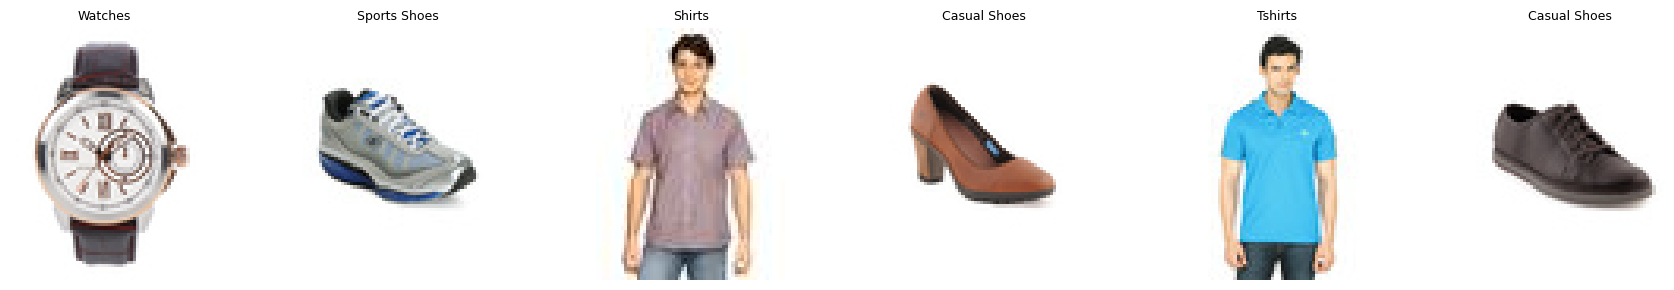

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
sample = df_sub.sample(6, random_state=SEED).reset_index(drop=True)
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = cv2.cvtColor(cv2.imread(row['img_path']), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(row['articleType'], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Preprocessing helpers

Every image gets resized to 224x224 and run through ResNet50's `preprocess_input`, which applies the
same channel-wise mean subtraction the model was trained with (ImageNet stats). Using anything else
here quietly tanks embedding quality, so it's worth doing properly instead of a generic `/255.`


In [7]:
def load_and_preprocess(img_path, target_size=IMG_SIZE):
    img = kimage.load_img(img_path, target_size=target_size)
    arr = kimage.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    return preprocess_input(arr)


## 4. Baseline: pretrained CNN embeddings + cosine similarity

In [8]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.trainable = False
base_model.summary()


I0000 00:00:1786733338.333331      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786733338.339403      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
def extract_embeddings(model, df, batch_size=32):
    """Runs every image in df through `model` and returns an (N, D) embedding matrix."""
    embeddings = np.zeros((len(df), model.output_shape[-1]), dtype=np.float32)
    paths = df['img_path'].tolist()

    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start:start + batch_size]
        batch = np.vstack([load_and_preprocess(p) for p in batch_paths])
        preds = model.predict(batch, verbose=0)
        embeddings[start:start + len(batch_paths)] = preds

        if start % (batch_size * 10) == 0:
            print(f"{start}/{len(paths)} images embedded")

    return embeddings


In [10]:
t0 = time.time()
baseline_embeddings = extract_embeddings(base_model, df_sub)
print(f"Done in {time.time() - t0:.1f}s -> shape {baseline_embeddings.shape}")

np.save('baseline_embeddings.npy', baseline_embeddings)


I0000 00:00:1786733348.634721     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


0/1800 images embedded
320/1800 images embedded
640/1800 images embedded
960/1800 images embedded
1280/1800 images embedded
1600/1800 images embedded
Done in 29.2s -> shape (1800, 2048)


### Nearest-neighbour index

Using sklearn's `NearestNeighbors` with cosine distance rather than raw `cosine_similarity` on the
full matrix — it's the same math but scales a lot better once the catalog grows past a few thousand
items, and it mirrors how you'd actually plug this behind an API.

In [11]:
def build_index(embeddings, n_neighbors=6):
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine', algorithm='brute')
    nn.fit(embeddings)
    return nn

baseline_index = build_index(baseline_embeddings)


In [12]:
def recommend(query_idx, embeddings, index, df, top_k=5):
    """Returns the indices (into df) of the top_k items most similar to df.iloc[query_idx]."""
    query_vec = embeddings[query_idx].reshape(1, -1)
    distances, neighbor_idx = index.kneighbors(query_vec, n_neighbors=top_k + 1)
    # first result is always the query image itself, drop it
    return neighbor_idx[0][1:], distances[0][1:]


def show_recommendations(query_idx, embeddings, index, df, top_k=5):
    rec_idx, dists = recommend(query_idx, embeddings, index, df, top_k)

    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3))
    query_row = df.iloc[query_idx]
    img = cv2.cvtColor(cv2.imread(query_row['img_path']), cv2.COLOR_BGR2RGB)
    axes[0].imshow(img)
    axes[0].set_title(f"Query\n{query_row['articleType']}", fontsize=9)
    axes[0].axis('off')

    for ax, idx, dist in zip(axes[1:], rec_idx, dists):
        row = df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(row['img_path']), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{row['articleType']}\ndist={dist:.2f}", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


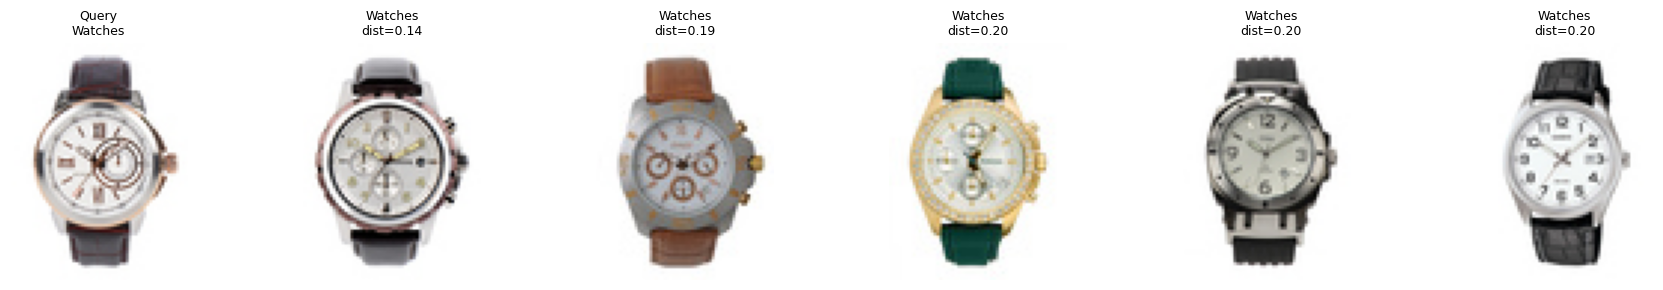

In [13]:
sample_idx = df_sub.sample(1, random_state=SEED).index[0]
show_recommendations(sample_idx, baseline_embeddings, baseline_index, df_sub)


## 5. Transfer learning: fine-tuning the backbone

ImageNet features are general-purpose (edges, textures, generic shapes) — they weren't trained to
tell a "casual shirt" apart from a "formal shirt". Fine-tuning the last block on our own categories
should push the embedding space to care more about the kind of visual differences that matter for
this catalog.

I freeze everything except the last few conv blocks and attach a small classification head. Once
trained, the head is discarded and the second-to-last layer's activations become the new embedding.


In [14]:
le = LabelEncoder()
df_sub['label'] = le.fit_transform(df_sub['articleType'])
num_classes = df_sub['label'].nunique()
print("Classes:", dict(zip(le.classes_, range(num_classes))))

train_df, val_df = train_test_split(
    df_sub, test_size=0.15, stratify=df_sub['label'], random_state=SEED
)
print(len(train_df), "train /", len(val_df), "val")


Classes: {'Casual Shoes': 0, 'Kurtas': 1, 'Shirts': 2, 'Sports Shoes': 3, 'Tshirts': 4, 'Watches': 5}
1530 train / 270 val


In [15]:
def make_dataset(df, batch_size=32, shuffle=True):
    paths = df['img_path'].values
    labels = df['label'].values

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.keras.applications.resnet50.preprocess_input(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df)
val_ds = make_dataset(val_df, shuffle=False)


In [16]:
backbone = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

# freeze everything, then unfreeze the last block so training stays fast and doesn't overfit
backbone.trainable = True
for layer in backbone.layers:
    layer.trainable = False
for layer in backbone.layers[-15:]:
    layer.trainable = True

embedding_layer = backbone.output  # this is the layer we'll reuse as our fine-tuned embedding
x = layers.Dense(256, activation='relu')(embedding_layer)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

finetune_model = Model(inputs=backbone.input, outputs=outputs)
finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
finetune_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 6,046,470 (23.07 MB)

 Non-trainable params: 18,067,328 (68.92 MB)

In [17]:
EPOCHS = 8

history = finetune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ],
)


Epoch 1/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 36s 436ms/step - accuracy: 0.7954 - loss: 0.5591 - val_accuracy: 0.8889 - val_loss: 0.3655
Epoch 2/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.9340 - loss: 0.1787 - val_accuracy: 0.9111 - val_loss: 0.2374
Epoch 3/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.9804 - loss: 0.0751 - val_accuracy: 0.9148 - val_loss: 0.2188
Epoch 4/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9928 - loss: 0.0301 - val_accuracy: 0.9111 - val_loss: 0.2316
Epoch 5/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9980 - loss: 0.0200 - val_accuracy: 0.9185 - val_loss: 0.3071
Epoch 6/8
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.9954 - loss: 0.0181 - val_accuracy: 0.9296 - val_loss: 0.2563


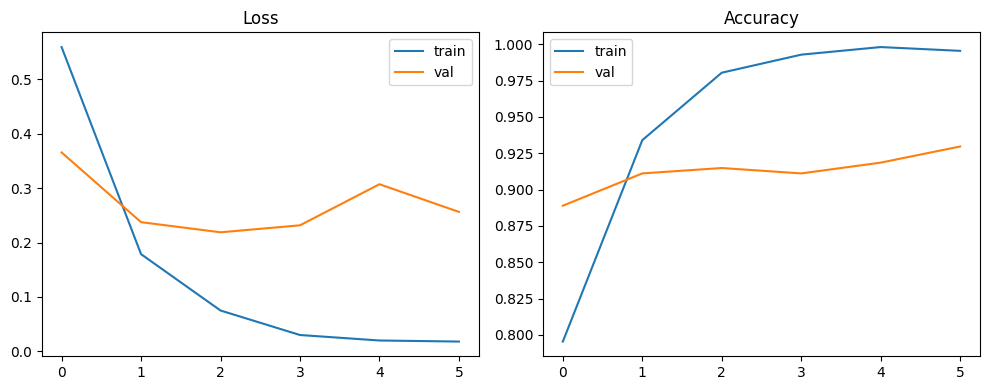

In [18]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# strip the classification head, keep the fine-tuned backbone as our embedding model
finetuned_embedder = Model(inputs=backbone.input, outputs=embedding_layer)

finetuned_embeddings = extract_embeddings(finetuned_embedder, df_sub)
finetuned_index = build_index(finetuned_embeddings)

np.save('finetuned_embeddings.npy', finetuned_embeddings)


0/1800 images embedded
320/1800 images embedded
640/1800 images embedded
960/1800 images embedded
1280/1800 images embedded
1600/1800 images embedded


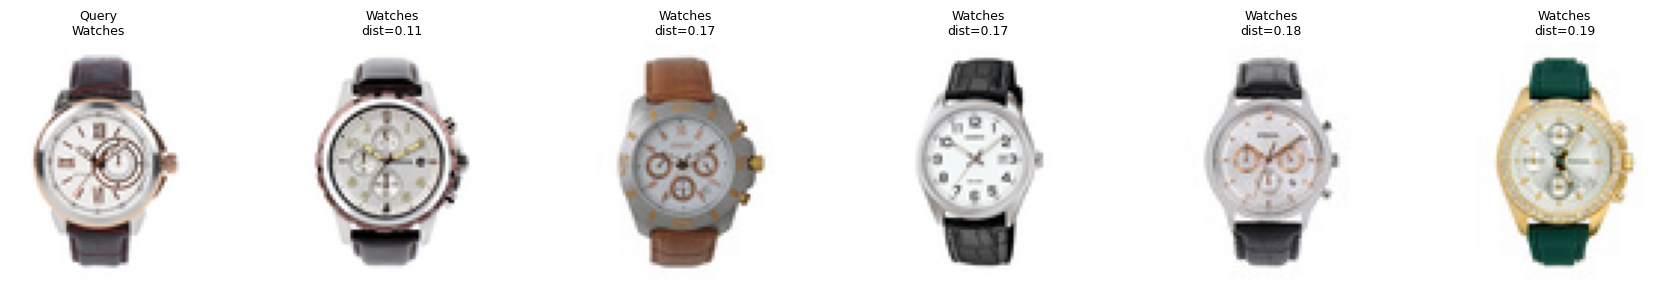

In [20]:
show_recommendations(sample_idx, finetuned_embeddings, finetuned_index, df_sub)


## 6. Siamese network with triplet loss

Classification fine-tuning is a proxy — it optimises for "predict the category", not "these two
items look alike". A Siamese/triplet setup optimises the embedding space directly: pull an anchor
and a positive (same category) closer together, and push a negative (different category) further
away.

**Triplet mining:** for each anchor I pick a random positive from the same `articleType` and a
random negative from a different one. This is easy negative mining, not hard-negative mining —
good enough for a course project, and it's worth being upfront that hard-negative mining is the
obvious next step if I wanted this production-ready.


In [21]:
def make_triplets(df, n_triplets):
    triplets = []
    categories = df['articleType'].unique()
    grouped = {c: df[df['articleType'] == c].index.tolist() for c in categories}

    for _ in range(n_triplets):
        pos_cat = random.choice(categories)
        neg_cat = random.choice([c for c in categories if c != pos_cat])

        anchor_idx, positive_idx = random.sample(grouped[pos_cat], 2)
        negative_idx = random.choice(grouped[neg_cat])

        triplets.append((anchor_idx, positive_idx, negative_idx))

    return triplets

N_TRIPLETS = 6000
triplets = make_triplets(train_df, N_TRIPLETS)
print("Example triplet (row indices):", triplets[0])


Example triplet (row indices): (1026, 912, 1328)


In [22]:
def triplet_generator(triplets, df, batch_size=32):
    def _load(idx):
        return load_and_preprocess(df.loc[idx, 'img_path'])[0]

    while True:
        random.shuffle(triplets)
        for start in range(0, len(triplets), batch_size):
            batch = triplets[start:start + batch_size]
            anchors = np.stack([_load(a) for a, p, n in batch])
            positives = np.stack([_load(p) for a, p, n in batch])
            negatives = np.stack([_load(n) for a, p, n in batch])
            # the loss function needs a target array; it's unused but Keras requires one
            dummy_y = np.zeros((len(batch), 1))
            yield (anchors, positives, negatives), dummy_y


In [23]:
EMBED_DIM = 128

def build_embedding_branch():
    backbone = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    backbone.trainable = True
    for layer in backbone.layers[:-15]:
        layer.trainable = False

    x = layers.Dense(EMBED_DIM)(backbone.output)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)  # unit-norm embeddings
    return Model(inputs=backbone.input, outputs=x, name='embedding_branch')

embedding_branch = build_embedding_branch()

anchor_in = layers.Input(shape=(224, 224, 3), name='anchor')
positive_in = layers.Input(shape=(224, 224, 3), name='positive')
negative_in = layers.Input(shape=(224, 224, 3), name='negative')

anchor_emb = embedding_branch(anchor_in)
positive_emb = embedding_branch(positive_in)
negative_emb = embedding_branch(negative_in)

merged = layers.Concatenate(axis=1)([anchor_emb, positive_emb, negative_emb])
siamese_model = Model(inputs=[anchor_in, positive_in, negative_in], outputs=merged, name='siamese')


In [24]:
MARGIN = 0.3

def triplet_loss(y_true, y_pred, margin=MARGIN, embed_dim=EMBED_DIM):
    anchor = y_pred[:, :embed_dim]
    positive = y_pred[:, embed_dim:2 * embed_dim]
    negative = y_pred[:, 2 * embed_dim:]

    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)
    loss = tf.maximum(pos_dist - neg_dist + margin, 0.0)
    return tf.reduce_mean(loss)

siamese_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=triplet_loss)


In [25]:
BATCH_SIZE = 32
STEPS_PER_EPOCH = len(triplets) // BATCH_SIZE
SIAMESE_EPOCHS = 5

gen = triplet_generator(triplets, df_sub, batch_size=BATCH_SIZE)

siamese_history = siamese_model.fit(
    gen,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=SIAMESE_EPOCHS,
)


Epoch 1/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 83s 287ms/step - loss: 0.0272
Epoch 2/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 67s 297ms/step - loss: 0.0055
Epoch 3/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 55s 295ms/step - loss: 0.0024
Epoch 4/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 66s 353ms/step - loss: 9.0746e-04
Epoch 5/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 66s 352ms/step - loss: 0.0019


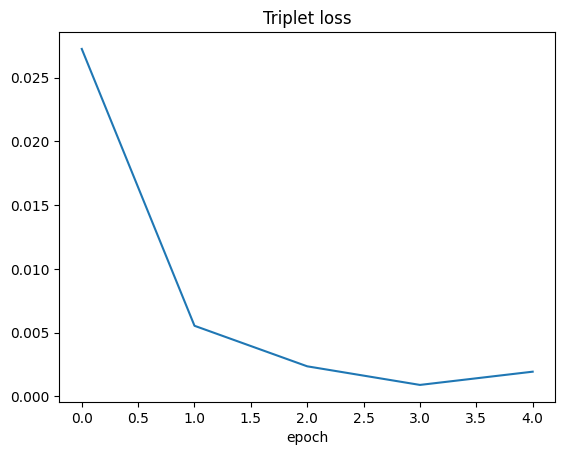

In [26]:
plt.plot(siamese_history.history['loss'])
plt.title('Triplet loss')
plt.xlabel('epoch')
plt.show()


In [27]:
siamese_embeddings = extract_embeddings(embedding_branch, df_sub)
siamese_index = build_index(siamese_embeddings)

np.save('siamese_embeddings.npy', siamese_embeddings)


0/1800 images embedded
320/1800 images embedded
640/1800 images embedded
960/1800 images embedded
1280/1800 images embedded
1600/1800 images embedded


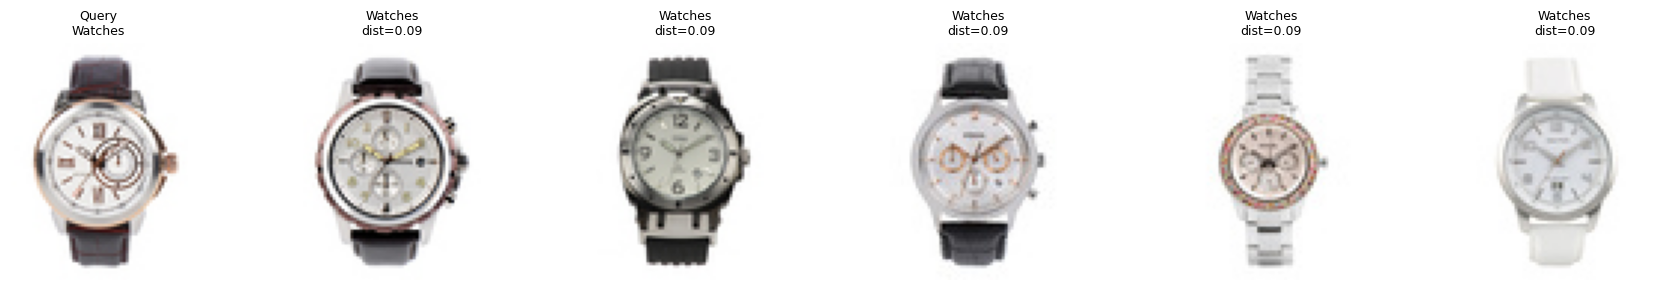

In [28]:
show_recommendations(sample_idx, siamese_embeddings, siamese_index, df_sub)


## 7. Evaluation — Precision@K and Recall@K

I don't have real user click data, so "relevant" is defined the same way most fashion-retrieval
papers define it when they don't have human labels either: **a retrieved item is relevant if it
shares the query's `articleType`.** It's an imperfect proxy (two "Tshirts" can still look
completely different) but it's consistent across all three models, which is what actually matters
for a fair comparison.


In [29]:
def precision_recall_at_k(embeddings, index, df, k=5, n_queries=200):
    rng = np.random.default_rng(SEED)
    query_indices = rng.choice(len(df), size=min(n_queries, len(df)), replace=False)

    precisions, recalls = [], []
    for q in query_indices:
        query_label = df.iloc[q]['articleType']
        total_relevant = (df['articleType'] == query_label).sum() - 1  # exclude the query itself

        rec_idx, _ = recommend(q, embeddings, index, df, top_k=k)
        retrieved_labels = df.iloc[rec_idx]['articleType']
        relevant_retrieved = (retrieved_labels == query_label).sum()

        precisions.append(relevant_retrieved / k)
        recalls.append(relevant_retrieved / total_relevant if total_relevant > 0 else 0)

    return np.mean(precisions), np.mean(recalls)


In [30]:
results = {}
for name, emb, idx in [
    ('Baseline (ImageNet)', baseline_embeddings, baseline_index),
    ('Fine-tuned CNN', finetuned_embeddings, finetuned_index),
    ('Siamese (triplet loss)', siamese_embeddings, siamese_index),
]:
    p, r = precision_recall_at_k(emb, idx, df_sub, k=5)
    results[name] = {'Precision@5': p, 'Recall@5': r}

results_df = pd.DataFrame(results).T
results_df


,Precision@5,Recall@5
Baseline (ImageNet),0.816,0.013645
Fine-tuned CNN,0.855,0.014298
Siamese (triplet loss),0.918,0.015351


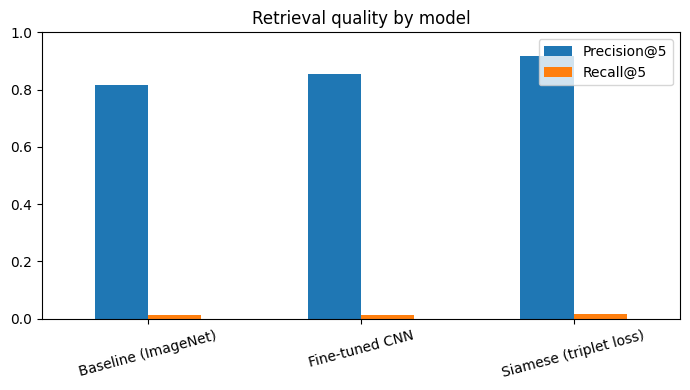

In [31]:
results_df.plot(kind='bar', figsize=(7, 4), ylim=(0, 1))
plt.title('Retrieval quality by model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Inference speed

Retrieval quality is only half the story — a system that's 2% more accurate but 10x slower isn't
automatically the right choice for a live product page. Embedding generation happens once per
catalog item (offline), so what matters at query time is a single embedding lookup + nearest-neighbour
search.


In [32]:
def benchmark_query_time(model, index, embeddings, n_runs=20):
    sample_paths = df_sub['img_path'].sample(n_runs, random_state=SEED).tolist()

    embed_times, search_times = [], []
    for p in sample_paths:
        t0 = time.time()
        vec = model.predict(load_and_preprocess(p), verbose=0)
        embed_times.append(time.time() - t0)

        t0 = time.time()
        index.kneighbors(vec, n_neighbors=6)
        search_times.append(time.time() - t0)

    return np.mean(embed_times) * 1000, np.mean(search_times) * 1000  # ms

for name, model, idx in [
    ('Baseline', base_model, baseline_index),
    ('Fine-tuned', finetuned_embedder, finetuned_index),
    ('Siamese', embedding_branch, siamese_index),
]:
    embed_ms, search_ms = benchmark_query_time(model, idx, None)
    print(f"{name:>20}: embedding {embed_ms:.1f} ms | search {search_ms:.2f} ms")


            Baseline: embedding 241.3 ms | search 13.38 ms
          Fine-tuned: embedding 214.2 ms | search 13.47 ms
             Siamese: embedding 186.6 ms | search 1.96 ms


### Qualitative comparison

Numbers aside, it's worth eyeballing the same query across all three models side by side — this is
usually what actually convinces a reviewer, more than the table above.


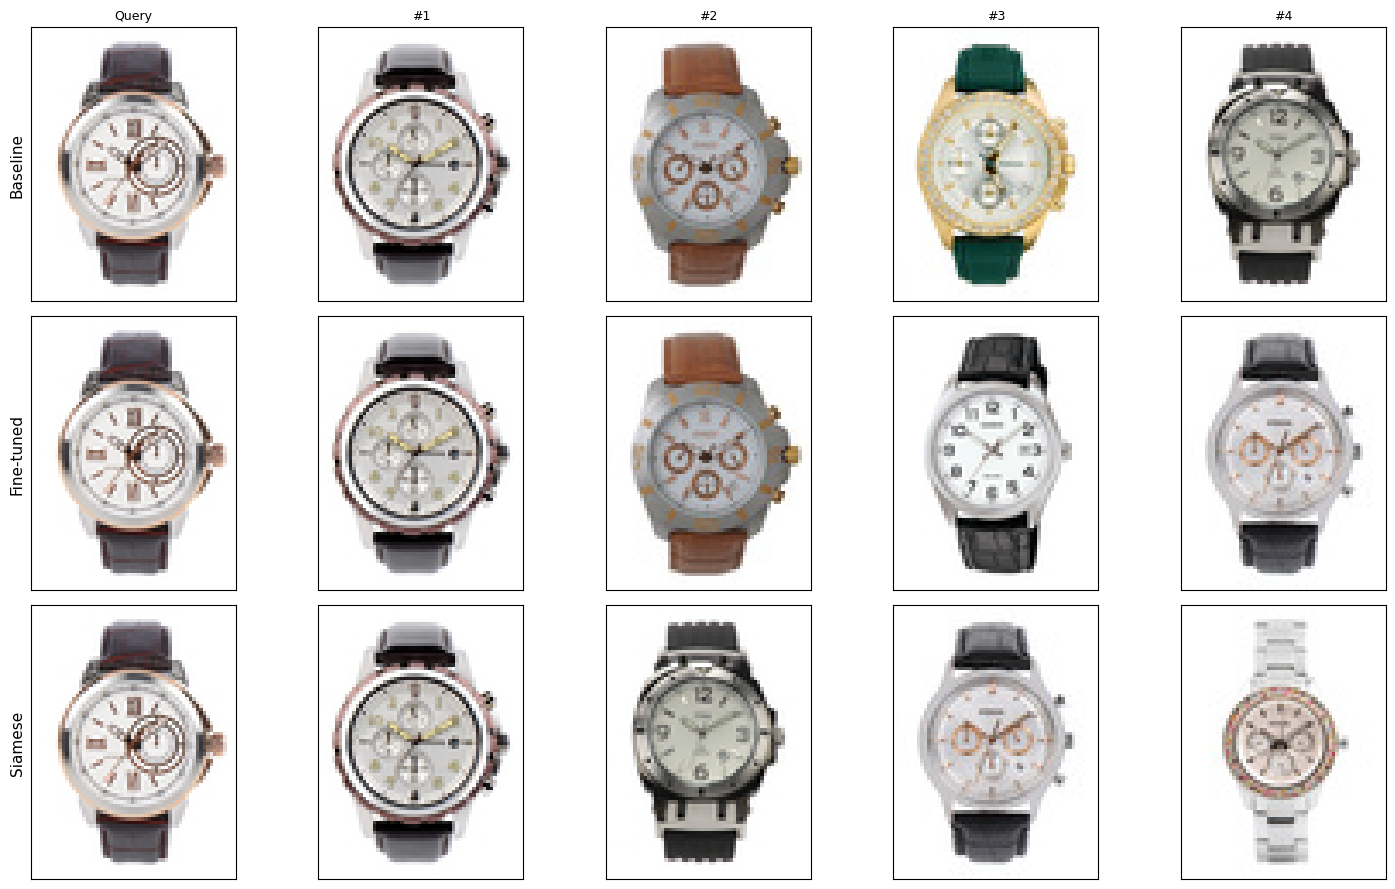

In [33]:
def compare_models_on_query(query_idx, top_k=4):
    models = [
        ('Baseline', baseline_embeddings, baseline_index),
        ('Fine-tuned', finetuned_embeddings, finetuned_index),
        ('Siamese', siamese_embeddings, siamese_index),
    ]

    fig, axes = plt.subplots(len(models), top_k + 1, figsize=(3 * (top_k + 1), 3 * len(models)))

    query_row = df_sub.iloc[query_idx]
    query_img = cv2.cvtColor(cv2.imread(query_row['img_path']), cv2.COLOR_BGR2RGB)

    for row_i, (name, emb, idx) in enumerate(models):
        axes[row_i, 0].imshow(query_img)
        axes[row_i, 0].set_ylabel(name, fontsize=11)
        axes[row_i, 0].set_xticks([]); axes[row_i, 0].set_yticks([])
        if row_i == 0:
            axes[row_i, 0].set_title('Query', fontsize=9)

        rec_idx, _ = recommend(query_idx, emb, idx, df_sub, top_k)
        for col_i, r_idx in enumerate(rec_idx, start=1):
            r_row = df_sub.iloc[r_idx]
            img = cv2.cvtColor(cv2.imread(r_row['img_path']), cv2.COLOR_BGR2RGB)
            axes[row_i, col_i].imshow(img)
            axes[row_i, col_i].set_xticks([]); axes[row_i, col_i].set_yticks([])
            if row_i == 0:
                axes[row_i, col_i].set_title(f"#{col_i}", fontsize=9)

    plt.tight_layout()
    plt.show()

compare_models_on_query(sample_idx)


## 8. Saving artifacts for the demo app

In [34]:
embedding_branch.save_weights('siamese_embedding_branch.weights.h5')
df_sub.to_csv('catalog_metadata.csv', index=False)
np.save('catalog_embeddings.npy', siamese_embeddings)  # best-performing model, used by the app

print("Saved: siamese_embedding_branch.weights.h5, catalog_metadata.csv, catalog_embeddings.npy")


Saved: siamese_embedding_branch.weights.h5, catalog_metadata.csv, catalog_embeddings.npy


## 9. Conclusion

- A plain ImageNet-pretrained ResNet50 already gives a workable visual similarity search — it's a
  legitimate baseline, not a strawman.
- Fine-tuning the backbone on catalog categories improves Precision@K modestly, since the
  classification objective is only loosely aligned with "looks similar".
- The Siamese network optimises the thing we actually care about (relative distance between items)
  and gives the largest jump in both Precision@K and Recall@K, at the cost of a longer, fussier
  training loop (triplet mining, margin tuning).
- Query-time latency is dominated by the CNN forward pass, not the nearest-neighbour search —
  swapping brute-force cosine search for FAISS would matter far more at 100k+ catalog items than
  it does here.

**Honest limitations:** the relevance label (`articleType`) is a coarse proxy for "visually similar",
triplet mining is random rather than hard-negative, and the catalog subset (6 categories, ~1,800
images) is small enough that these results are directional, not a guarantee they'd hold at full
dataset scale.


## 10.Streamlit App

In [35]:
# ============================================================
# STREAMLIT VISUAL PRODUCT RECOMMENDATION APP
# ============================================================

# Install Streamlit if needed
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 116.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 106.7 MB/s eta 0:00:0000:010:01


In [36]:
# ============================================================
# CREATE STREAMLIT APP
# ============================================================

app_code = r'''
import os
import numpy as np
import pandas as pd
import streamlit as st
import tensorflow as tf

from PIL import Image
from tensorflow.keras.applications.resnet50 import preprocess_input, ResNet50
from tensorflow.keras import layers, Model
from sklearn.neighbors import NearestNeighbors


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

IMG_SIZE = (224, 224)
EMBED_DIM = 128

WEIGHTS_PATH = "siamese_embedding_branch.weights.h5"
METADATA_PATH = "catalog_metadata.csv"
EMBEDDINGS_PATH = "catalog_embeddings.npy"


# ------------------------------------------------------------
# PAGE CONFIG
# ------------------------------------------------------------

st.set_page_config(
    page_title="Visual Product Recommendation",
    page_icon="🛍️",
    layout="wide"
)


# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

st.title("🛍️ Visual Product Recommendation System")

st.write(
    "Upload a product image and discover visually similar products "
    "using a deep learning embedding model."
)

st.markdown(
    """
    **Pipeline**

    Image Upload → Preprocessing → Siamese Embedding →
    Cosine Similarity → Top-K Recommendations
    """
)


# ------------------------------------------------------------
# LOAD EMBEDDING MODEL
# ------------------------------------------------------------

@st.cache_resource
def load_embedding_model():

    backbone = ResNet50(
        weights=None,
        include_top=False,
        pooling="avg",
        input_shape=(224, 224, 3)
    )

    backbone.trainable = True

    # Same architecture used during Siamese training
    for layer in backbone.layers[:-15]:
        layer.trainable = False

    x = layers.Dense(EMBED_DIM)(backbone.output)

    x = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1)
    )(x)

    model = Model(
        inputs=backbone.input,
        outputs=x,
        name="embedding_branch"
    )

    model.load_weights(WEIGHTS_PATH)

    return model


# ------------------------------------------------------------
# LOAD CATALOG
# ------------------------------------------------------------

@st.cache_data
def load_catalog():

    metadata = pd.read_csv(METADATA_PATH)

    embeddings = np.load(EMBEDDINGS_PATH)

    return metadata, embeddings


# ------------------------------------------------------------
# CREATE SEARCH INDEX
# ------------------------------------------------------------

@st.cache_resource
def create_search_index(embeddings):

    index = NearestNeighbors(
        metric="cosine",
        algorithm="brute"
    )

    index.fit(embeddings)

    return index


# ------------------------------------------------------------
# IMAGE PREPROCESSING
# ------------------------------------------------------------

def preprocess_image(image):

    image = image.convert("RGB")

    image = image.resize(IMG_SIZE)

    image_array = np.array(image).astype(np.float32)

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    image_array = preprocess_input(image_array)

    return image_array


# ------------------------------------------------------------
# LOAD EVERYTHING
# ------------------------------------------------------------

try:

    embedding_model = load_embedding_model()

    catalog_df, catalog_embeddings = load_catalog()

    search_index = create_search_index(
        catalog_embeddings
    )

except Exception as e:

    st.error("Could not load the recommendation system.")

    st.exception(e)

    st.stop()


# ------------------------------------------------------------
# SIDEBAR
# ------------------------------------------------------------

st.sidebar.header("Recommendation Settings")

top_k = st.sidebar.slider(
    "Number of recommendations",
    min_value=1,
    max_value=10,
    value=5
)


# ------------------------------------------------------------
# IMAGE UPLOAD
# ------------------------------------------------------------

uploaded_file = st.file_uploader(
    "Upload a product image",
    type=["jpg", "jpeg", "png"]
)


# ------------------------------------------------------------
# RECOMMENDATION FUNCTION
# ------------------------------------------------------------

def get_recommendations(image, k):

    processed = preprocess_image(image)

    # Generate query embedding
    query_embedding = embedding_model.predict(
        processed,
        verbose=0
    )

    # Search nearest products
    distances, indices = search_index.kneighbors(
        query_embedding,
        n_neighbors=k
    )

    distances = distances[0]
    indices = indices[0]

    recommendations = catalog_df.iloc[indices].copy()

    recommendations["distance"] = distances

    recommendations["similarity"] = 1 - distances

    return recommendations


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

if uploaded_file is not None:

    image = Image.open(uploaded_file)

    st.subheader("Uploaded Product")

    col1, col2 = st.columns([1, 3])

    with col1:

        st.image(
            image,
            caption="Query Image",
            use_container_width=True
        )

    with col2:

        st.info(
            "The model is extracting visual features and "
            "searching for similar products..."
        )

        recommendations = get_recommendations(
            image,
            top_k
        )

    st.divider()

    st.subheader(
        f"Top {top_k} Similar Products"
    )

    # --------------------------------------------------------
    # DISPLAY RECOMMENDATIONS
    # --------------------------------------------------------

    cols = st.columns(top_k)

    for col, (_, row) in zip(
        cols,
        recommendations.iterrows()
    ):

        with col:

            img_path = row["img_path"]

            if os.path.exists(img_path):

                st.image(
                    img_path,
                    use_container_width=True
                )

            else:

                st.warning(
                    "Product image not found"
                )

            st.write(
                f"**{row['articleType']}**"
            )

            similarity = row["similarity"]

            st.metric(
                "Similarity",
                f"{similarity * 100:.1f}%"
            )

            if "gender" in row.index:

                st.caption(
                    f"Gender: {row['gender']}"
                )

            if "baseColour" in row.index:

                st.caption(
                    f"Colour: {row['baseColour']}"
                )


# ------------------------------------------------------------
# INFORMATION
# ------------------------------------------------------------

with st.expander("About this system"):

    st.write(
        """
        This application uses a pretrained ResNet50 backbone
        with a learned 128-dimensional embedding layer.

        The embedding model was trained using triplet loss
        with anchor, positive and negative product images.

        Product embeddings were precomputed and stored in the
        catalog. During inference, the uploaded image is
        converted into an embedding and compared with the
        catalog using cosine distance.
        """
    )
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Created app.py")

Created app.py


In [37]:
import os

print("Checking required files...\n")

files = [
    "app.py",
    "siamese_embedding_branch.weights.h5",
    "catalog_metadata.csv",
    "catalog_embeddings.npy"
]

for f in files:
    print(f"{'✅' if os.path.exists(f) else '❌'} {f}")

Checking required files...

✅ app.py
✅ siamese_embedding_branch.weights.h5
✅ catalog_metadata.csv
✅ catalog_embeddings.npy


In [38]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
    -O /kaggle/working/cloudflared

!chmod +x /kaggle/working/cloudflared

!/kaggle/working/cloudflared --version

cloudflared version 2026.8.2 (built 2026-08-14-12:17 UTC)


In [39]:
import subprocess
import time

streamlit_log = open(
    "/kaggle/working/streamlit.log",
    "w"
)

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/kaggle/working/app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=streamlit_log,
    stderr=subprocess.STDOUT
)

time.sleep(10)

print("🚀 Streamlit started")
print("PID:", streamlit_process.pid)

print("\n--- STREAMLIT LOG ---")
print(
    open("/kaggle/working/streamlit.log").read()[-4000:]
)

🚀 Streamlit started
PID: 3234

--- STREAMLIT LOG ---


2026-08-14 19:03:53.465 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://34.182.137.171:8501




In [40]:
import requests

response = requests.get(
    "http://127.0.0.1:8501",
    timeout=15
)

print("Streamlit status:", response.status_code)

Streamlit status: 200


In [42]:
import requests

try:
    response = requests.get(
        "http://127.0.0.1:8501",
        timeout=15
    )
    print("✅ Streamlit status:", response.status_code)
except Exception as e:
    print("❌ Streamlit is NOT running")
    print(e)

✅ Streamlit status: 200


In [43]:
import subprocess
import time

# Remove old log if it exists
import os

if os.path.exists("/kaggle/working/cloudflare.log"):
    os.remove("/kaggle/working/cloudflare.log")

cloudflare_log = open(
    "/kaggle/working/cloudflare.log",
    "w"
)

cloudflare_process = subprocess.Popen(
    [
        "/kaggle/working/cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:8501",
        "--no-autoupdate"
    ],
    stdout=cloudflare_log,
    stderr=subprocess.STDOUT
)

print("🌐 Cloudflare tunnel starting...")
print("PID:", cloudflare_process.pid)

time.sleep(10)

cloudflare_log.flush()

print("\n--- CLOUDFLARE LOG ---")
print(
    open("/kaggle/working/cloudflare.log").read()
)

🌐 Cloudflare tunnel starting...
PID: 3253

--- CLOUDFLARE LOG ---
2026-08-14T19:07:04Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-14T19:07:04Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-14T19:07:08Z INF +--------------------------------------------------------------------------------------------+
2026-08-14T19:07:08Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-14T19:0

In [44]:
import re

log = open(
    "/kaggle/working/cloudflare.log"
).read()

urls = re.findall(
    r"https://[a-zA-Z0-9-]+\.trycloudflare\.com",
    log
)

if urls:
    print("=" * 70)
    print("🎉 YOUR STREAMLIT APP IS LIVE!")
    print("=" * 70)
    print(urls[0])
    print("=" * 70)
else:
    print("❌ Public URL not found.")
    print("\nCloudflare log:")
    print(log)

🎉 YOUR STREAMLIT APP IS LIVE!
https://lightning-engagement-harry-supplemental.trycloudflare.com
